# 교육부_학생건강검사 결과 (2015학년도)
> 데이터 출처: [공공데이터포털](https://www.data.go.kr/data/15051017/fileData.do)
>
> 이 자료는 서울 지역 학생들의 건강검사 결과를 표본조사 방식으로 수집한 것으로, 신체 치수와 생화학적 검사를 포함한다. 키, 몸무게, 혈당, 콜레스테롤, 간기능 수치 및 혈색소 등 다양한 건강 지표가 포함되어 있으며, 도시규모별, 성별, 학년별 분석이 가능하다. 특히 건강검진일과 개별 학생의 고유식별번호가 부여되어 상세한 추적과 비교 연구에 활용할 수 있다. 이러한 데이터는 학생들의 전반적 건강 상태를 평가하고 지역사회 건강 관리에 유용한 기초 자료로 활용된다.

- 서울 지역 초,중,고등학생들의 건강검사 결과를 수집한 것이다.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
data = pd.read_csv('교육부_학생건강검사 결과_20151201.csv', encoding='cp949')

In [26]:
data.head()

,고유식별번호(ID),최종가중치,학교고유번호(ID),도시규모,도시규모별분석용,학년도,광역시도,시도별,학교급별,학교명,...,키,몸무게,혈당식전(mgdl),총콜레스테롤(mgdl),간기능(AST)단위(UL),간기능(ALT)단위(UL),혈색소(gdl),간염검사,수축기,이완기
0,Aa011남10101,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,125.8,27.3,NaN,NaN,NaN,NaN,NaN,NaN,77.0,58.0
1,Aa011남10102,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,124.3,25.4,NaN,NaN,NaN,NaN,NaN,NaN,83.0,51.0
2,Aa011남10103,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,119.2,23.5,NaN,NaN,NaN,NaN,NaN,NaN,103.0,65.0
3,Aa011남10104,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,115.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,92.0,66.0
4,Aa011남10105,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,120.0,33.5,NaN,NaN,NaN,NaN,NaN,NaN,102.0,59.0


- 수치형 데이터는 **키**, **몸무게**, **혈당식전**, **총콜레스테롤** 등 건강 지표 데이터들이 있다.
- 범주형 데이터는 **학교명**, **공학여부**, **학년**, **성별** 등이 있다.

In [27]:
print(data.dtypes)
print(data.shape)

고유식별번호(ID)            str
최종가중치             float64
학교고유번호(ID)            str
도시규모                  str
도시규모별분석용              str
학년도                 int64
광역시도                  str
시도별                   str
학교급별                int64
학교명                   str
공학여부                  str
학년                  int64
반                   int64
성별                    str
건강검진일                 str
키                 float64
몸무게               float64
혈당식전(mgdl)        float64
총콜레스테롤(mgdl)      float64
간기능(AST)단위(UL)    float64
간기능(ALT)단위(UL)    float64
혈색소(gdl)          float64
간염검사                  str
수축기               float64
이완기               float64
dtype: object
(9686, 25)


In [28]:
data.describe()

,최종가중치,학년도,학교급별,학년,반,키,몸무게,혈당식전(mgdl),총콜레스테롤(mgdl),간기능(AST)단위(UL),간기능(ALT)단위(UL),혈색소(gdl),수축기,이완기
count,9686.000000,9686.0,9686.000000,9686.000000,9686.000000,9686.000000,9682.000000,338.00000,339.000000,336.000000,337.000000,578.000000,3025.000000,3025.000000
mean,104.894487,2015.0,1.995767,2.567933,2.659096,154.564444,50.207591,92.14497,173.516519,27.824405,30.311573,12.976990,104.830083,62.987438
std,39.376988,0.0,0.856499,1.414243,2.601067,16.968590,17.075953,10.49571,32.567571,19.327395,32.191960,1.092454,12.661348,7.948402
min,23.325794,2015.0,1.000000,1.000000,1.000000,107.700000,15.900000,65.00000,102.000000,11.000000,8.000000,9.000000,65.000000,23.000000
25%,76.966829,2015.0,1.000000,1.000000,1.000000,142.000000,37.200000,85.00000,148.500000,19.000000,14.000000,12.400000,98.000000,60.000000
50%,99.963287,2015.0,2.000000,2.000000,1.000000,158.700000,50.700000,91.00000,170.000000,24.000000,20.000000,13.200000,105.000000,62.000000
75%,133.231158,2015.0,3.000000,3.000000,3.000000,167.200000,60.600000,99.00000,191.000000,30.000000,32.000000,13.675000,112.000000,69.000000
max,248.300844,2015.0,3.000000,6.000000,15.000000,194.200000,130.700000,132.00000,300.000000,186.000000,272.000000,15.700000,180.000000,98.000000


In [29]:
data.shape

(9686, 25)

In [30]:
data.value_counts() # NaN이 포함된 행이 대부분이다.

고유식별번호(ID)   최종가중치       학교고유번호(ID)  도시규모      도시규모별분석용  학년도   광역시도  시도별       학교급별  학교명       공학여부  학년  반  성별  건강검진일       키      몸무게   혈당식전(mgdl)  총콜레스테롤(mgdl)  간기능(AST)단위(UL)  간기능(ALT)단위(UL)  혈색소(gdl)  간염검사  수축기    이완기 
Ac031여10104  118.778262  Ac03        대도시/중소도시  특별/광역시    2015  서울    서울특별시교육청  3     동명여자고등학교  여자    1   1  여   2015-05-07  159.7  71.1  102.0       175.0         19.0            18.0            13.3      음성    119.0  72.0    1
Ac031여10105  118.778262  Ac03        대도시/중소도시  특별/광역시    2015  서울    서울특별시교육청  3     동명여자고등학교  여자    1   1  여   2015-05-07  151.1  57.4  91.0        170.0         15.0            12.0            15.7      음성    142.0  87.0    1
Ac031여10115  118.778262  Ac03        대도시/중소도시  특별/광역시    2015  서울    서울특별시교육청  3     동명여자고등학교  여자    1   1  여   2015-05-07  152.8  49.3  98.0        135.0         24.0            29.0            12.1      음성    114.0  83.0    1
Ac031여10123  118.778262  Ac03        대도시/중소도시  특별/광역시    2015  서울    서울특별시교육청  3     동명여자고등학교

In [31]:
data.isnull().sum() # 마지막 8개 열이 결측치를 매우 많이 포함하고 있다.

고유식별번호(ID)           0
최종가중치                0
학교고유번호(ID)           0
도시규모                 0
도시규모별분석용             0
학년도                  0
광역시도                 0
시도별                  0
학교급별                 0
학교명                  0
공학여부                 0
학년                   0
반                    0
성별                   0
건강검진일                0
키                    0
몸무게                  4
혈당식전(mgdl)        9348
총콜레스테롤(mgdl)      9347
간기능(AST)단위(UL)    9350
간기능(ALT)단위(UL)    9349
혈색소(gdl)          9108
간염검사              8855
수축기               6661
이완기               6661
dtype: int64

In [ ]:
data['간염검사'].dropna() # 유효한 값이 무엇이 있나 확인

3573    음성
3574    음성
3575    음성
3576    음성
3577    음성
        ..
6417    음성
6418    음성
6419    음성
6420    음성
6421    음성
Name: 간염검사, Length: 831, dtype: str

In [40]:
columns = ['몸무게', '혈당식전(mgdl)', '총콜레스테롤(mgdl)', '간기능(AST)단위(UL)', '간기능(ALT)단위(UL)', '혈색소(gdl)', '수축기', '이완기']
data[columns] = data[columns].fillna(data[columns].mean()) # 실수형 데이터는 결측치를 평균으로 대체하고
data['간염검사'] = data['간염검사'].fillna('음성')               # 간염검사를 하지 않은 경우는 검사결과 음성으로 대체한다.
data.head()

,고유식별번호(ID),최종가중치,학교고유번호(ID),도시규모,도시규모별분석용,학년도,광역시도,시도별,학교급별,학교명,...,키,몸무게,혈당식전(mgdl),총콜레스테롤(mgdl),간기능(AST)단위(UL),간기능(ALT)단위(UL),혈색소(gdl),간염검사,수축기,이완기
0,Aa011남10101,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,125.8,27.3,92.14497,173.516519,27.824405,30.311573,12.97699,음성,77.0,58.0
1,Aa011남10102,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,124.3,25.4,92.14497,173.516519,27.824405,30.311573,12.97699,음성,83.0,51.0
2,Aa011남10103,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,119.2,23.5,92.14497,173.516519,27.824405,30.311573,12.97699,음성,103.0,65.0
3,Aa011남10104,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,115.0,20.0,92.14497,173.516519,27.824405,30.311573,12.97699,음성,92.0,66.0
4,Aa011남10105,169.550665,Aa01,대도시/중소도시,특별/광역시,2015,서울,서울특별시교육청,1,서울대도초등학교,...,120.0,33.5,92.14497,173.516519,27.824405,30.311573,12.97699,음성,102.0,59.0


In [41]:
data.isnull().sum()

고유식별번호(ID)        0
최종가중치             0
학교고유번호(ID)        0
도시규모              0
도시규모별분석용          0
학년도               0
광역시도              0
시도별               0
학교급별              0
학교명               0
공학여부              0
학년                0
반                 0
성별                0
건강검진일             0
키                 0
몸무게               0
혈당식전(mgdl)        0
총콜레스테롤(mgdl)      0
간기능(AST)단위(UL)    0
간기능(ALT)단위(UL)    0
혈색소(gdl)          0
간염검사              0
수축기               0
이완기               0
dtype: int64

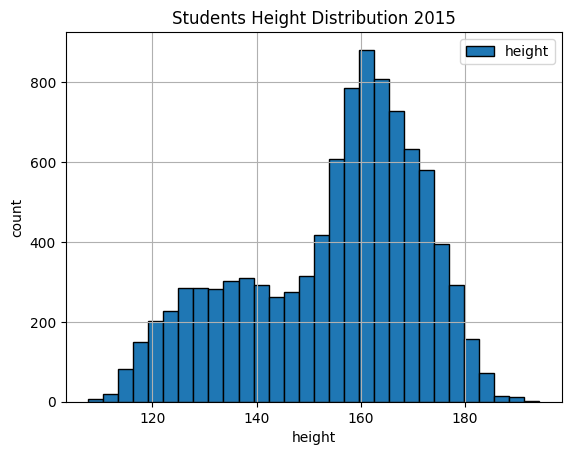

In [42]:
ax = data['키'].hist(bins=30, edgecolor='k', label='height')
ax.set(xlabel='height', ylabel='count')
ax.set_title('Students Height Distribution 2015')
ax.legend()
plt.show()